# GNN Techniques for Social Network Analysis 
**SNA Tasks Covered:**

1) Node Classification

2) Link Prediction (Graph Auto-Encoder)

3) Community Detection (Differentiable Pooling, semi-supervised)

4) Diffusion / Influence Prediction (GAT: attention-based)

5) Graph Anomaly Detection (DOMINANT-style)

> Minimal PyTorch implementations (no PyG/DGL). Synthetic graphs (SBM).

## Setup

In [1]:

import os, warnings
os.environ["KMP_WARNINGS"] = "0"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["MKL_SERVICE_FORCE_INTEL"] = "1"
warnings.filterwarnings("ignore", category=UserWarning)

import math, random
import numpy as np
import networkx as nx
import urllib.request
import gzip
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# Set device and random seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)


In [7]:
# GCN model definition
def sparse_mm(A, X): 
    return A @ X

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, bias=True):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=bias)
    def forward(self, A_hat, X):
        return self.lin(sparse_mm(A_hat, X))

class GCN(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim, dropout=0.2):
        super().__init__()
        self.g1 = GCNLayer(in_dim, hid_dim)
        self.g2 = GCNLayer(hid_dim, out_dim)
        self.dropout = dropout
    def forward(self, A_hat, X):
        H = F.relu(self.g1(A_hat, X))
        H = F.dropout(H, p=self.dropout, training=self.training)
        Z = self.g2(A_hat, H)
        return Z


### Synthetic Data

In [3]:
# Create random SBM graph with features and labels
def to_norm_adj(G):
    n = G.number_of_nodes()
    idx_map = {n_id:i for i, n_id in enumerate(G.nodes())}
    rows, cols = [], []
    for u, v in G.edges():
        ui, vi = idx_map[u], idx_map[v]
        rows += [ui, vi]; cols += [vi, ui]
    indices = torch.tensor([rows, cols], dtype=torch.long)
    values = torch.ones(indices.shape[1], dtype=torch.float32)
    A = torch.sparse_coo_tensor(indices, values, (n, n)).to_dense()
    deg = A.sum(1).clamp(min=1.0)
    D_inv_sqrt = torch.pow(deg, -0.5)
    D = torch.diag(D_inv_sqrt)
    A_hat = D @ A @ D
    return A_hat.to(device)

def make_sbm(n_per_comm=100, p_in=0.08, p_out=0.01, num_comms=3, feat_dim=16, noise=0.5):
    sizes = [n_per_comm]*num_comms
    probs = [[p_in if i==j else p_out for j in range(num_comms)] for i in range(num_comms)]
    G = nx.stochastic_block_model(sizes, probs, seed=seed)
    labels = []
    for i, size in enumerate(sizes):
        labels += [i]*size
    y = torch.tensor(labels, dtype=torch.long, device=device)
    centroids = torch.eye(num_comms, feat_dim, device=device)[:num_comms]
    X = torch.zeros((sum(sizes), feat_dim), device=device)
    start = 0
    for c, size in enumerate(sizes):
        X[start:start+size] = centroids[c] + noise*torch.randn(size, feat_dim, device=device)
        start += size
    A = to_norm_adj(G)
    return A, X, y, G

# Split node indices into train/val/test sets
def split_idx(n, val_ratio=0.1, test_ratio=0.2):
    idx = np.arange(n)
    idx_train, idx_tmp = train_test_split(idx, test_size=val_ratio+test_ratio, random_state=seed)
    rel_test = test_ratio/(val_ratio+test_ratio)
    idx_val, idx_test = train_test_split(idx_tmp, test_size=rel_test, random_state=seed)
    return torch.tensor(idx_train), torch.tensor(idx_val), torch.tensor(idx_test)

In [69]:
A, X, y, G = make_sbm(n_per_comm=120, p_in=0.08, p_out=0.01, num_comms=3, feat_dim=16, noise=0.6)
n, in_dim = X.shape
num_classes = int(y.max().item()+1)
idx_tr, idx_val, idx_te = split_idx(n)

model = GCN(in_dim, 32, num_classes, dropout=0.3).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

best_val, best = 0.0, None
for epoch in range(200):
    model.train()
    logits = model(A, X)
    loss = F.cross_entropy(logits[idx_tr], y[idx_tr])
    opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        val_acc = (logits[idx_val].argmax(1) == y[idx_val]).float().mean().item()
        if val_acc > best_val:
            best_val, best = val_acc, {k:v.detach().clone() for k,v in model.state_dict().items()}
    if epoch % 50 == 0:
        print(f"[Epoch {epoch}] loss={loss.item():.4f} val_acc={val_acc:.3f}")
model.load_state_dict(best)
model.eval()
with torch.no_grad():
    logits = model(A, X)
    te_acc = (logits[idx_te].argmax(1) == y[idx_te]).float().mean().item()
print("Node Classification Test Accuracy:", round(te_acc,3))

[Epoch 0] loss=1.1033 val_acc=0.194
[Epoch 50] loss=0.0394 val_acc=1.000
[Epoch 100] loss=0.0161 val_acc=1.000
[Epoch 150] loss=0.0115 val_acc=1.000
Node Classification Test Accuracy: 0.973


### Real Data

In [5]:
# Load Facebook Social Circles dataset (SNAP)

data_dir_fb = "data/facebook"
os.makedirs(data_dir_fb, exist_ok=True)
file_path_fb = os.path.join(data_dir_fb, "facebook_combined.txt.gz")

if not os.path.exists(file_path_fb):
    print("Downloading facebook_combined.txt.gz ...")
    url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
    urllib.request.urlretrieve(url, file_path_fb)

txt_path_fb = file_path_fb.replace(".gz", "")
if not os.path.exists(txt_path_fb):
    with gzip.open(file_path_fb, 'rb') as f_in:
        with open(txt_path_fb, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

G_fb = nx.read_edgelist(txt_path_fb, nodetype=int)
G_fb = nx.convert_node_labels_to_integers(G_fb)
print(f"[Facebook] Graph: {G_fb.number_of_nodes()} nodes, {G_fb.number_of_edges()} edges")


[Facebook] Graph: 4039 nodes, 88234 edges


In [6]:
#Pre-process the real dataset
import torch, numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Node features (degree, clustering, noise) ---
deg_fb = np.array([val for _, val in G_fb.degree()])
clust_fb = np.array(list(nx.clustering(G_fb).values()))
feat_fb = np.vstack([
    (deg_fb - deg_fb.mean()) / (deg_fb.std() + 1e-6),
    (clust_fb - clust_fb.mean()) / (clust_fb.std() + 1e-6)
]).T
rand_fb = np.random.randn(G_fb.number_of_nodes(), 6)
X_fb = torch.tensor(np.hstack([feat_fb, rand_fb]), dtype=torch.float32, device=device)
print("[Facebook] Feature matrix:", X_fb.shape)

# --- Normalized adjacency ---
def to_norm_adj(G):
    n = G.number_of_nodes()
    idx_map = {n_id:i for i, n_id in enumerate(G.nodes())}
    rows, cols = zip(*[(idx_map[u], idx_map[v]) for u,v in G.edges()])
    rows, cols = list(rows), list(cols)
    indices = torch.tensor([rows+cols, cols+rows])
    values = torch.ones(len(rows)*2)
    A = torch.sparse_coo_tensor(indices, values, (n,n)).to_dense()
    deg = A.sum(1).clamp(min=1.0)
    D_inv_sqrt = torch.pow(deg, -0.5)
    D = torch.diag(D_inv_sqrt)
    return (D @ A @ D).to(device)

A_fb = to_norm_adj(G_fb)
print("[Facebook] Adjacency matrix:", A_fb.shape)




[Facebook] Feature matrix: torch.Size([4039, 8])
[Facebook] Adjacency matrix: torch.Size([4039, 4039])


## 1) Node Classification

### Synthetic Data

In [ ]:

# Centrality metrics
deg_cent = np.array(list(nx.degree_centrality(G).values()))
eig_cent = np.array(list(nx.eigenvector_centrality_numpy(G).values()))
bet_cent = np.array(list(nx.betweenness_centrality(G).values()))

# Combined influence score (normalize each metric)
inf_score = (deg_cent / deg_cent.max() +
             eig_cent / eig_cent.max() / 2.0 +
             bet_cent / bet_cent.max()) / 2.0

# Label top 10% as influencers
threshold = np.percentile(inf_score, 90)
y_influencer = torch.tensor((inf_score >= threshold).astype(int), dtype=torch.long, device=device)

print(f"Influencers: {y_influencer.sum().item()} / {len(y_influencer)} "
      f"({100*y_influencer.float().mean().item():.1f}%)")


Influencers: 36 / 360 (10.0%)


In [17]:
model_inf = GCN(X.shape[1], 64, 2).to(device)
opt = torch.optim.Adam(model_inf.parameters(), lr=0.01, weight_decay=5e-4)

idx = np.arange(G.number_of_nodes())
idx_train, idx_test = train_test_split(idx, test_size=0.3, stratify=y_influencer.cpu(), random_state=42)
idx_train = torch.tensor(idx_train, device=device)
idx_test = torch.tensor(idx_test, device=device)

best_acc, best_state = 0, None
for epoch in range(150):
    model_inf.train()
    out = model_inf(A, X)
    loss = torch.nn.functional.cross_entropy(out[idx_train], y_influencer[idx_train])
    opt.zero_grad(); loss.backward(); opt.step()
    model_inf.eval()
    with torch.no_grad():
        preds = out[idx_test].argmax(1)
        acc = (preds == y_influencer[idx_test]).float().mean().item()
    if acc > best_acc:
        best_acc = acc
        best_state = {k:v.clone() for k,v in model_inf.state_dict().items()}
    if epoch % 30 == 0:
        print(f"[Epoch {epoch}] loss={loss.item():.4f} acc={acc:.3f}")

model_inf.load_state_dict(best_state)
print(f"Influencer Classification Test Accuracy: {best_acc:.3f}")


[Epoch 0] loss=0.7780 acc=0.102
[Epoch 30] loss=0.3691 acc=0.898
[Epoch 60] loss=0.3584 acc=0.898
[Epoch 90] loss=0.3453 acc=0.898
[Epoch 120] loss=0.3261 acc=0.898
Influencer Classification Test Accuracy: 0.898


/var/folders/5x/87gs962j3hzbnvy7dy2jv5280000gn/T/ipykernel_94123/1689874646.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  nodes = nx.draw_networkx_nodes(G, pos, node_color=probs, cmap=cm.get_cmap("YlOrRd"), node_size=50)


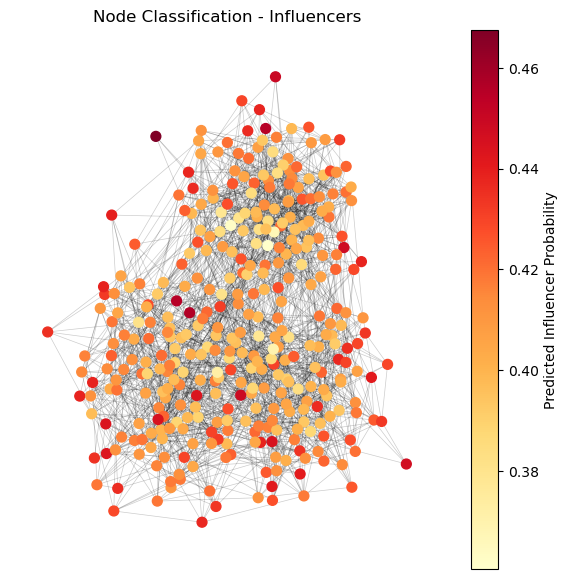

In [19]:
# Visualize influencer predictions
model_inf.eval()
with torch.no_grad():
    logits = model_inf(A, X)
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # influencer prob
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(7,7))
nodes = nx.draw_networkx_nodes(G, pos, node_color=probs, cmap=cm.get_cmap("YlOrRd"), node_size=50)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)
plt.colorbar(nodes, label="Predicted Influencer Probability")
plt.title("Node Classification - Influencers")
plt.axis('off')
plt.show()


### Real Data

In [ ]:
# Influencer labels based on combined centrality for fb data
deg_cent_fb = np.array(list(nx.degree_centrality(G_fb).values()))
eig_cent_fb = np.array(list(nx.eigenvector_centrality_numpy(G_fb).values()))
bet_cent_fb = np.array(list(nx.betweenness_centrality(G_fb).values()))

inf_score_fb = (deg_cent_fb/deg_cent_fb.max() +
                eig_cent_fb/eig_cent_fb.max() / 2.0 +
                bet_cent_fb/bet_cent_fb.max()) / 2.0

threshold_fb = np.percentile(inf_score_fb, 90)
y_influencer_fb = torch.tensor((inf_score_fb >= threshold_fb).astype(int),
                               dtype=torch.long, device=device)

print(f"[Facebook] Influencers: {y_influencer_fb.sum().item()} / "
      f"{len(y_influencer_fb)} ({100*y_influencer_fb.float().mean():.1f}%)")


Facebook Influencers: 404 / 4039 (10.0%)


In [21]:
# Training the GCN on the real Facebook data
from sklearn.model_selection import train_test_split

model_inf_fb = GCN(X_fb.shape[1], 64, 2).to(device)
opt_fb = torch.optim.Adam(model_inf_fb.parameters(), lr=0.01, weight_decay=5e-4)

idx_fb = np.arange(G_fb.number_of_nodes())
idx_train_fb, idx_test_fb = train_test_split(idx_fb, test_size=0.3,
                                             stratify=y_influencer_fb.cpu(), random_state=42)
idx_train_fb = torch.tensor(idx_train_fb, device=device)
idx_test_fb = torch.tensor(idx_test_fb, device=device)

best_acc_fb, best_state_fb = 0, None
for epoch in range(150):
    model_inf_fb.train()
    out_fb = model_inf_fb(A_fb, X_fb)
    loss_fb = torch.nn.functional.cross_entropy(out_fb[idx_train_fb], y_influencer_fb[idx_train_fb])
    opt_fb.zero_grad(); loss_fb.backward(); opt_fb.step()
    model_inf_fb.eval()
    with torch.no_grad():
        preds_fb = out_fb[idx_test_fb].argmax(1)
        acc_fb = (preds_fb == y_influencer_fb[idx_test_fb]).float().mean().item()
    if acc_fb > best_acc_fb:
        best_acc_fb = acc_fb
        best_state_fb = {k:v.clone() for k,v in model_inf_fb.state_dict().items()}
    if epoch % 30 == 0:
        print(f"[Facebook][Epoch {epoch}] loss={loss_fb.item():.4f} acc={acc_fb:.3f}")

model_inf_fb.load_state_dict(best_state_fb)
print(f"[Facebook] Influencer Classification Accuracy: {best_acc_fb:.3f}")



[Facebook][Epoch 0] loss=0.7101 acc=0.177
[Facebook][Epoch 30] loss=0.1919 acc=0.955
[Facebook][Epoch 60] loss=0.1794 acc=0.957
[Facebook][Epoch 90] loss=0.1703 acc=0.960
[Facebook][Epoch 120] loss=0.1609 acc=0.963
[Facebook] Influencer Classification Accuracy: 0.969


/var/folders/5x/87gs962j3hzbnvy7dy2jv5280000gn/T/ipykernel_94123/2209451.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  nodes_fb = nx.draw_networkx_nodes(G_fb, pos_fb, node_color=probs_fb, cmap=cm.get_cmap("YlOrRd"), node_size=20)


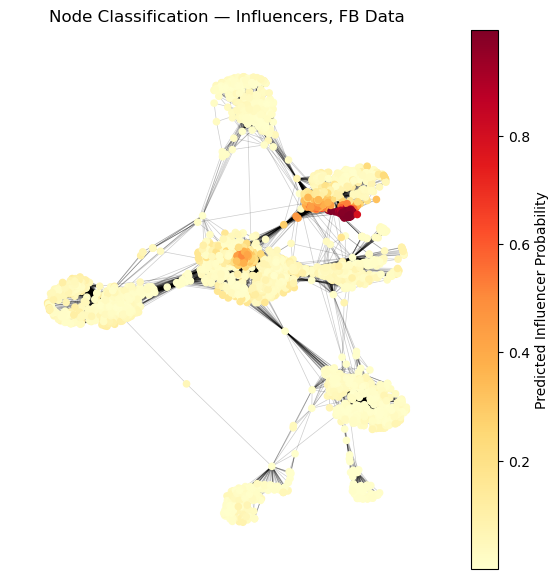

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

model_inf_fb.eval()
with torch.no_grad():
    logits_fb = model_inf_fb(A_fb, X_fb)
    probs_fb = torch.softmax(logits_fb, dim=1)[:, 1].cpu().numpy()

pos_fb = nx.spring_layout(G_fb, seed=42)
plt.figure(figsize=(7,7))
nodes_fb = nx.draw_networkx_nodes(G_fb, pos_fb, node_color=probs_fb, cmap=cm.get_cmap("YlOrRd"), node_size=20)
nx.draw_networkx_edges(G_fb, pos_fb, alpha=0.2, width=0.5)
plt.colorbar(nodes_fb, label="Predicted Influencer Probability")
plt.title("Node Classification — Influencers, FB Data")
plt.axis('off')
plt.show()


## 2) Link Prediction (Graph Auto-Encoder)

### Synthetic Data

In [23]:
# link prediction with GAE on SBM data
A_dense = (A > 0).float()
edges = torch.nonzero(A_dense, as_tuple=False)
mask = edges[:,0] < edges[:,1]
edges = edges[mask]

def sample_neg(num_samples):
    neg = []
    n_nodes = A_dense.shape[0]
    seen = set()
    while len(neg) < num_samples:
        i = np.random.randint(0, n_nodes); j = np.random.randint(0, n_nodes)
        if i==j: continue
        a,b = (i,j) if i<j else (j,i)
        if (a,b) in seen: continue
        if A_dense[a,b]==0:
            neg.append([a,b]); seen.add((a,b))
    return torch.tensor(neg, device=device)

class GAE(nn.Module):
    def __init__(self, in_dim, hid_dim, emb_dim, dropout=0.2):
        super().__init__()
        self.enc = GCN(in_dim, hid_dim, emb_dim, dropout)
    def forward(self, A_hat, X):
        return self.enc(A_hat, X)
    def decode(self, Z, pairs):
        z_i, z_j = Z[pairs[:,0]], Z[pairs[:,1]]
        return torch.sigmoid((z_i * z_j).sum(dim=1))

gae = GAE(in_dim, 64, 32, 0.2).to(device)
opt = torch.optim.Adam(gae.parameters(), lr=0.01)

train_pos, test_pos = train_test_split(edges.cpu().numpy(), test_size=0.2, random_state=seed)
train_pos = torch.tensor(train_pos, device=device)
test_pos = torch.tensor(test_pos, device=device)
test_neg = sample_neg(len(test_pos))

for epoch in range(150):
    gae.train()
    Z = gae(A, X)
    pos = train_pos
    neg = sample_neg(len(pos))
    y_true = torch.cat([torch.ones(len(pos), device=device), torch.zeros(len(neg), device=device)])
    y_pred = torch.cat([gae.decode(Z, pos), gae.decode(Z, neg)])
    loss = F.binary_cross_entropy(y_pred, y_true)
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 30 == 0:
        with torch.no_grad():
            gae.eval(); Z = gae(A, X)
            s_pos = gae.decode(Z, test_pos).cpu().numpy()
            s_neg = gae.decode(Z, test_neg).cpu().numpy()
            y = np.concatenate([np.ones_like(s_pos), np.zeros_like(s_neg)])
            s = np.concatenate([s_pos, s_neg])
            auc = roc_auc_score(y, s); ap = average_precision_score(y, s)
            print(f"[Epoch {epoch}] loss={loss.item():.4f} AUC={auc:.3f} AP={ap:.3f}")
with torch.no_grad():
    gae.eval(); Z = gae(A, X)
    s_pos = gae.decode(Z, test_pos).cpu().numpy()
    s_neg = gae.decode(Z, test_neg).cpu().numpy()
    y = np.concatenate([np.ones_like(s_pos), np.zeros_like(s_neg)])
    s = np.concatenate([s_pos, s_neg])
    auc = roc_auc_score(y, s); ap = average_precision_score(y, s)
print("Link Prediction Test AUC:", round(auc,3), "AP:", round(ap,3))


[Epoch 0] loss=0.7189 AUC=0.743 AP=0.715
[Epoch 30] loss=0.5790 AUC=0.806 AP=0.772
[Epoch 60] loss=0.5774 AUC=0.808 AP=0.773
[Epoch 90] loss=0.5802 AUC=0.808 AP=0.770
[Epoch 120] loss=0.5702 AUC=0.805 AP=0.771
Link Prediction Test AUC: 0.806 AP: 0.766


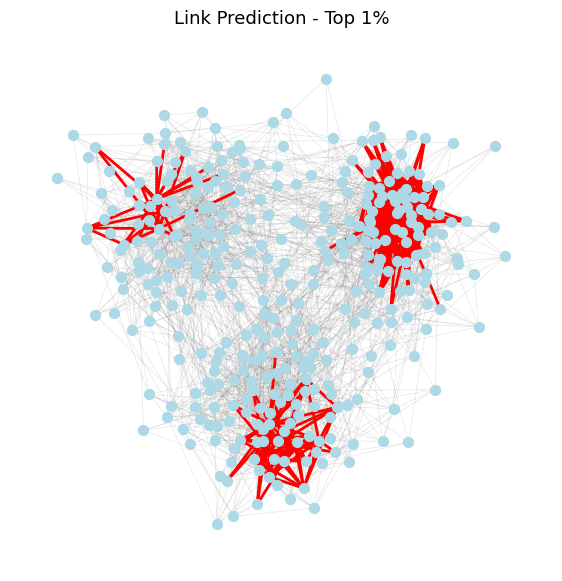

In [ ]:
# Visualize top-K predicted new edges
with torch.no_grad():
    out = gae(A, X)
    Z = out[0] if isinstance(out, tuple) else out
    scores = torch.sigmoid(Z @ Z.T).cpu().numpy()

existing = (A.cpu().numpy() > 0).astype(int)
n_nodes = existing.shape[0]

# Flatten upper triangle (no self-loops)
triu_idx = np.triu_indices(n_nodes, k=1)
pred_scores = scores[triu_idx]
existing_mask = existing[triu_idx] == 0  # exclude existing edges
non_existing_scores = pred_scores[existing_mask]

# Select top-K strongest predictions

# Map back to node pairs
non_existing_pairs = np.column_stack(triu_idx)
percentile = 99  # show top 1%
threshold = np.percentile(non_existing_scores, percentile)
pred_pairs = non_existing_pairs[existing_mask][non_existing_scores >= threshold]
predicted_edges = [(int(i), int(j)) for i, j in pred_pairs]

G_pred = G.copy()
G_pred.add_edges_from(predicted_edges)


pos = nx.spring_layout(G_pred, seed=42)
plt.figure(figsize=(7,7))
nx.draw_networkx_edges(G_pred, pos, alpha=0.2, width=0.5, edge_color='gray')
nx.draw_networkx_edges(G_pred, pos, edgelist=predicted_edges, edge_color='red', width=2)
nx.draw_networkx_nodes(G_pred, pos, node_color='lightblue', node_size=50)
plt.title(f"Link Prediction - Top 1%", fontsize=13)
plt.axis('off')
plt.show()


### Real Data

In [25]:
# link prediction on real Facebook data

class GAE_fb(torch.nn.Module):
    def __init__(self, in_dim, hid_dim):
        super().__init__()
        self.gc1 = torch.nn.Linear(in_dim, hid_dim)
        self.gc2 = torch.nn.Linear(hid_dim, hid_dim)
    def forward(self, A, X):
        H = torch.relu(self.gc1(A @ X))
        Z = self.gc2(A @ H)
        return Z

gae_fb = GAE_fb(X_fb.shape[1], 64).to(device)
opt_gae_fb = torch.optim.Adam(gae_fb.parameters(), lr=0.01)

for epoch in range(200):
    gae_fb.train()
    Z_fb = gae_fb(A_fb, X_fb)
    A_pred_fb = torch.sigmoid(Z_fb @ Z_fb.T)
    loss_fb = ((A_fb - A_pred_fb)**2).mean()
    opt_gae_fb.zero_grad(); loss_fb.backward(); opt_gae_fb.step()
    if epoch % 50 == 0:
        print(f"[FB][GAE Epoch {epoch}] loss={loss_fb.item():.4f}")

print("Facebook Link Prediction Model Trained")



[FB][GAE Epoch 0] loss=0.5108
[FB][GAE Epoch 50] loss=0.2501
[FB][GAE Epoch 100] loss=0.2498
[FB][GAE Epoch 150] loss=0.2498
Facebook Link Prediction Model Trained ✅


[Facebook] Visualizing top 0.00100% = 37 predicted edges


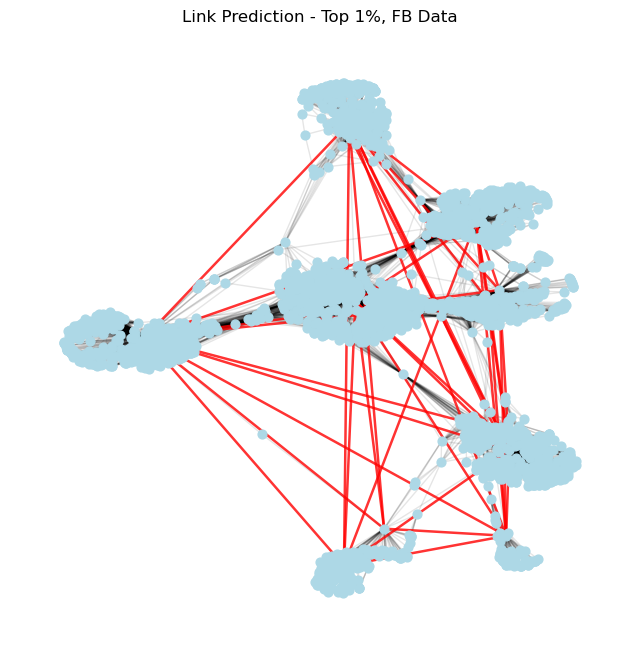

In [ ]:
# Visualize top-K predicted new edges on Facebook data`
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

with torch.no_grad():
    Z_fb = gae_fb(A_fb, X_fb)
    scores_fb = torch.sigmoid(Z_fb @ Z_fb.T).cpu().numpy()

# Remove existing edges (so we only show *newly* predicted ones)
existing_fb = (A_fb.cpu().numpy() > 0).astype(int)
scores_fb[existing_fb == 1] = 0

#  Select top 1% highest scoring pairs
num_nodes_fb = scores_fb.shape[0]
num_pairs_fb = num_nodes_fb * (num_nodes_fb - 1) / 2
top_percent = 0.00001  
topk_fb = int(top_percent * num_pairs_fb)

# Get indices of top-scoring pairs
flat_indices_fb = np.argpartition(scores_fb.flatten(), -topk_fb)[-topk_fb:]
row_fb, col_fb = np.unravel_index(flat_indices_fb, scores_fb.shape)
pred_edges_fb = [(int(i), int(j)) for i, j in zip(row_fb, col_fb) if i < j]

print(f"[Facebook] Visualizing top {100*top_percent:.5f}% = {len(pred_edges_fb)} predicted edges")

# Visualization
pos_fb = nx.spring_layout(G_fb, seed=42)

plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(G_fb, pos_fb, alpha=0.1, width=1, edge_color="black")
nx.draw_networkx_edges(G_fb, pos_fb, edgelist=pred_edges_fb, edge_color="red", width=1.8, alpha=0.8)
nx.draw_networkx_nodes(G_fb, pos_fb, node_color="lightblue", node_size=40)
plt.title("Link Prediction - Top 1%, FB Data")
plt.axis("off"); plt.show()


## 3) Community Detection 

### Synthetic Data

In [ ]:
# Recreate graph to ensure matching dimensions
A, X, y, G = make_sbm(n_per_comm=100, p_in=0.08, p_out=0.01, num_comms=3, feat_dim=16, noise=0.5)

# Verify consistent dimensions
print("A:", A.shape, "X:", X.shape, "y:", y.shape)

num_clusters = int(y.max().item() + 1)

class AssignNet(nn.Module):
    def __init__(self, in_dim, hid_dim, num_clusters, dropout=0.2):
        super().__init__()
        self.gcn = GCN(in_dim, hid_dim, num_clusters, dropout)
    def forward(self, A_hat, X):
        logits = self.gcn(A_hat, X)
        S = torch.softmax(logits, dim=1)
        return S, logits

assigner = AssignNet(X.shape[1], 32, num_clusters, 0.2).to(device)
opt = torch.optim.Adam(assigner.parameters(), lr=0.01)

def entropy(S, eps=1e-8):
    P = S.clamp_min(eps)
    return -(P * P.log()).sum(dim=1).mean()

for epoch in range(200):
    assigner.train()
    S, logits = assigner(A, X)
    ce = F.cross_entropy(logits, y)   
    ent = entropy(S)
    loss = ce + 0.05*ent
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        with torch.no_grad():
            acc = (S.argmax(1) == y).float().mean().item()
            print(f"[Epoch {epoch}] loss={loss.item():.4f} cluster_acc={acc:.3f}")


A: torch.Size([300, 300]) X: torch.Size([300, 16]) y: torch.Size([300])
[Epoch 0] loss=1.1304 cluster_acc=0.333
[Epoch 50] loss=0.0652 cluster_acc=0.993
[Epoch 100] loss=0.0223 cluster_acc=1.000
[Epoch 150] loss=0.0151 cluster_acc=1.000


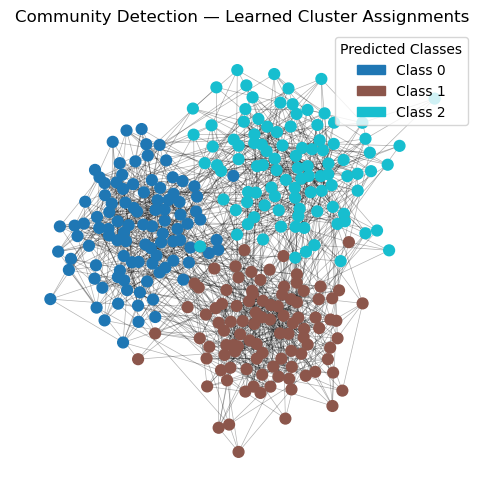

In [ ]:
# Visualize discovered communities
import matplotlib.patches as mpatches

with torch.no_grad():
    S, _ = assigner(A, X)
    communities = S.argmax(1).cpu().numpy()

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(6,6))
cmap = plt.get_cmap('tab10')
nodes = nx.draw_networkx_nodes(G, pos, node_color=communities, cmap=cmap, node_size=60)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5)
plt.title("Community Detection — Learned Cluster Assignments", fontsize=12)
plt.axis('off')

# Legend for communities
unique_comms = np.unique(communities)
# Create legend with matching colors
handles = [mpatches.Patch(color=cmap(c / (len(unique_comms)-1 if len(unique_comms)>1 else 1)), 
                          label=f"Class {c}") for c in unique_comms]
plt.legend(handles=handles, loc='lower left', frameon=True, title="Predicted Classes")
plt.show()


### Real Data

In [31]:
class AssignNet_fb(torch.nn.Module):
    def __init__(self, in_dim, hid_dim, clusters):
        super().__init__()
        self.gc = torch.nn.Linear(in_dim, hid_dim)
        self.assign = torch.nn.Linear(hid_dim, clusters)
    def forward(self, A, X):
        H = torch.relu(self.gc(A @ X))
        S = torch.softmax(self.assign(H), dim=1)
        logits = S @ S.T
        return S, logits

assigner_fb = AssignNet_fb(X_fb.shape[1], 64, clusters=6).to(device)
opt_assign_fb = torch.optim.Adam(assigner_fb.parameters(), lr=0.01)
entropy = lambda S: -torch.sum(S * torch.log(S + 1e-8)) / S.shape[0]

for epoch in range(100):
    assigner_fb.train()
    S_fb, logits_fb = assigner_fb(A_fb, X_fb)
    loss_fb = ((A_fb - logits_fb)**2).mean() + 0.05 * entropy(S_fb)
    opt_assign_fb.zero_grad(); loss_fb.backward(); opt_assign_fb.step()
    if epoch % 20 == 0:
        print(f"[FB][Community Epoch {epoch}] loss={loss_fb.item():.4f}")

S_fb, _ = assigner_fb(A_fb, X_fb)
clusters_fb = S_fb.argmax(1).cpu().numpy()


[FB][Community Epoch 0] loss=0.1176
[FB][Community Epoch 20] loss=0.1060
[FB][Community Epoch 40] loss=0.1014
[FB][Community Epoch 60] loss=0.0999
[FB][Community Epoch 80] loss=0.0982


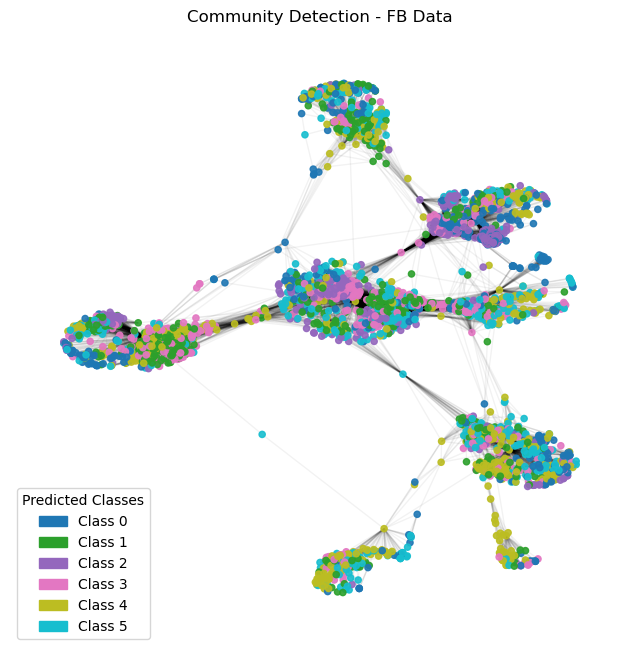

In [ ]:
# Visualize Facebook communities
plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(G_fb, pos_fb, alpha=0.05, width=1, edge_color="black")
nx.draw_networkx_nodes(
    G_fb,
    pos_fb,
    node_color=clusters_fb,  # from assigner_fb
    cmap="tab10",
    node_size=20,
    alpha=0.9,
)
plt.title("Community Detection - Learned Clusters (FB Data)")
# Legend for communities
unique_comms = np.unique(clusters_fb)
# Create legend with matching colors
handles = [mpatches.Patch(color=cmap(c / (len(unique_comms)-1 if len(unique_comms)>1 else 1)), 
                          label=f"Class {c}") for c in unique_comms]
plt.legend(handles=handles, loc='lower left', frameon=True, title="Predicted Classes")
plt.axis("off")
plt.show()



## 4) Diffusion / Influence Prediction (attention-based)

### Synthetic Data

In [ ]:

def simulate_diffusion(G, base_rate=0.01, peer_influence=0.25, steps=10, num_seeds_ratio=0.02, rng_seed=123):

    rng = np.random.default_rng(rng_seed)
    n = G.number_of_nodes()
    num_seeds = max(1, int(num_seeds_ratio * n))

    seeds = rng.choice(n, size=num_seeds, replace=False)
    adopted = np.zeros(n, dtype=np.int32)
    adopted[seeds] = 1

    snapshots = [adopted.copy()]   # step 0

    # precompute neighbors list for speed
    idx_map = {node:i for i, node in enumerate(G.nodes())}
    neighbors = [np.fromiter((idx_map[u] for u in G.neighbors(v)), dtype=int)
                 for v in G.nodes()]

    for _ in range(steps):
        new_adopted = adopted.copy()
        for v in range(n):
            if adopted[v] == 1:
                continue
            neigh = neighbors[v]
            if neigh.size == 0:
                p = base_rate
            else:
                frac = adopted[neigh].mean()
                p = base_rate + peer_influence * frac
            if rng.random() < p:
                new_adopted[v] = 1
        adopted = new_adopted
        snapshots.append(adopted.copy())

    y_final = torch.tensor(adopted, device=device).long()
    return y_final, snapshots


In [34]:

class SimpleGATLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
        self.att = nn.Linear(2*out_dim, 1, bias=False)
    def forward(self, A_hat, X):
        H = self.lin(X)
        E = (A_hat > 0).float()
        rows, cols = E.nonzero(as_tuple=True)
        h_i, h_j = H[rows], H[cols]
        e = F.leaky_relu(self.att(torch.cat([h_i, h_j], dim=1))).squeeze(-1)
        # softmax per row
        order = torch.argsort(rows)
        rows_s, cols_s, e_s = rows[order], cols[order], e[order]
        out = torch.zeros_like(H)
        uniq = rows_s.unique()
        start = 0
        for r in uniq:
            mask = (rows_s == r)
            e_row = e_s[mask]
            a_row = torch.softmax(e_row, dim=0)
            msgs = H[cols_s[mask]] * a_row.unsqueeze(-1)
            out[r] = msgs.sum(dim=0)
        return F.elu(out)

class SimpleGAT(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim):
        super().__init__()
        self.g1 = SimpleGATLayer(in_dim, hid_dim)
        self.g2 = SimpleGATLayer(hid_dim, hid_dim)
        self.out = nn.Linear(hid_dim, out_dim)
    def forward(self, A_hat, X):
        H = self.g1(A_hat, X)
        H = self.g2(A_hat, H)
        return self.out(H)

y_diff, snapshots = simulate_diffusion(G,
    base_rate=0.01,        # spontaneous adoption
    peer_influence=0.25,   # strength from neighbors
    steps=10,              # more steps => deeper cascades
    num_seeds_ratio=0.02,  # ~2% seeds
    rng_seed=42
)

print(f"Final adoption: {int(y_diff.sum())}/{len(y_diff)} "
      f"({100*y_diff.float().mean().item():.1f}%)")

idx_tr, idx_te = train_test_split(np.arange(len(y_diff)), test_size=0.3, random_state=seed, stratify=y_diff.cpu().numpy())
idx_tr = torch.tensor(idx_tr, device=device); idx_te = torch.tensor(idx_te, device=device)

gat = SimpleGAT(in_dim, 32, 2).to(device)
opt = torch.optim.Adam(gat.parameters(), lr=0.01, weight_decay=1e-4)

best_acc, best = 0.0, None
for epoch in range(200):
    gat.train()
    logits = gat(A, X)
    loss = F.cross_entropy(logits[idx_tr], y_diff[idx_tr])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 40 == 0:
        gat.eval()
        with torch.no_grad():
            acc = (logits[idx_te].argmax(1) == y_diff[idx_te]).float().mean().item()
            print(f"[Epoch {epoch}] loss={loss.item():.4f} val_acc={acc:.3f}")
            if acc > best_acc:
                best_acc, best = acc, {k:v.detach().clone() for k,v in gat.state_dict().items()}
if best:
    gat.load_state_dict(best)
gat.eval()
with torch.no_grad():
    logits = gat(A, X)
    acc = (logits[idx_te].argmax(1) == y_diff[idx_te]).float().mean().item()
print("Diffusion Prediction Test Accuracy:", round(acc,3))


Final adoption: 91/300 (30.3%)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
[Epoch 0] loss=0.6637 val_acc=0.700
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will requir

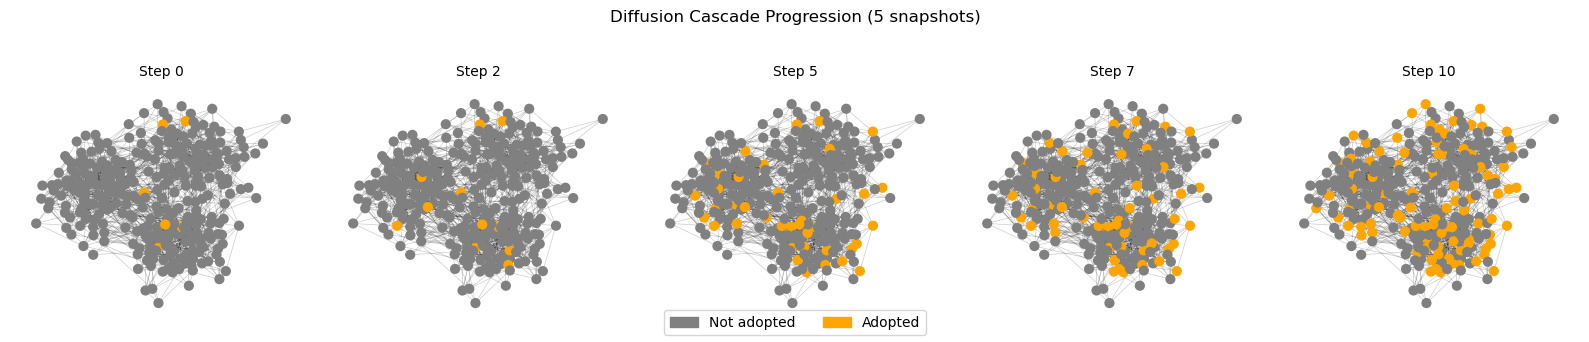

In [ ]:
# Visualize diffusion snapshots
import matplotlib.patches as mpatches

# Use a stable layout so positions don't jump across panels
pos = nx.spring_layout(G, seed=42)

# Choose 5 evenly spaced time indices across the full timeline
k = min(5, len(snapshots))                      # in case there are fewer than 5
idxs = np.linspace(0, len(snapshots)-1, k, dtype=int)

fig, axes = plt.subplots(1, k, figsize=(3.2*k, 3.2))
# Handle the case where k==1 (axes isn't an array)
if k == 1:
    axes = np.array([axes])

for ax, t in zip(axes, idxs):
    adopted = snapshots[t]                      # np.ndarray of 0/1
    # Colors
    colors = np.where(adopted==1, 'orange', 'gray')
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=40, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5, ax=ax)
    ax.set_title(f"Step {t}", fontsize=10)
    ax.axis('off')

# Legend across the figure
gray_patch = mpatches.Patch(color='gray', label='Not adopted')
orange_patch = mpatches.Patch(color='orange', label='Adopted')
fig.legend(handles=[gray_patch, orange_patch], loc='lower center', ncol=2, frameon=True)

fig.suptitle("Diffusion Cascade Progression", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


### Real Data

In [55]:
def simulate_diffusion_fb(G_fb, base_rate=0.01, peer_influence=0.25,
                          steps=10, num_seeds_ratio=0.02, rng_seed=123):
    rng = np.random.default_rng(rng_seed)
    n = G_fb.number_of_nodes()
    num_seeds = max(1, int(num_seeds_ratio * n))

    seeds = rng.choice(n, size=num_seeds, replace=False)
    adopted = np.zeros(n, dtype=np.int32)
    adopted[seeds] = 1

    snapshots_fb = [adopted.copy()]  # step 0
    idx_map_fb = {node:i for i, node in enumerate(G_fb.nodes())}
    neighbors_fb = [np.fromiter((idx_map_fb[u] for u in G_fb.neighbors(v)), dtype=int)
                    for v in G_fb.nodes()]

    for _ in range(steps):
        new_adopted = adopted.copy()
        for v in range(n):
            if adopted[v] == 1:
                continue
            neigh = neighbors_fb[v]
            if neigh.size == 0:
                p = base_rate
            else:
                frac = adopted[neigh].mean()
                p = base_rate + peer_influence * frac
            if rng.random() < p:
                new_adopted[v] = 1
        adopted = new_adopted
        snapshots_fb.append(adopted.copy())

    y_final_fb = torch.tensor(adopted, device=device).long()
    return y_final_fb, snapshots_fb

# Run diffusion
y_diff_fb, snapshots_fb = simulate_diffusion_fb(
    G_fb,
    base_rate=0.01,
    peer_influence=0.25,
    steps=10,
    num_seeds_ratio=0.02,
    rng_seed=42
)

print(f"[Facebook] Final adoption: {int(y_diff_fb.sum())}/{len(y_diff_fb)} "
      f"({100*y_diff_fb.float().mean().item():.1f}%)")


[Facebook] Final adoption: 1392/4039 (34.5%)


In [57]:
class SimpleGATLayer_fb(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
        self.att = nn.Linear(2*out_dim, 1, bias=False)
    def forward(self, A_hat, X):
        H = self.lin(X)
        E = (A_hat > 0).float()
        rows, cols = E.nonzero(as_tuple=True)
        h_i, h_j = H[rows], H[cols]
        e = F.leaky_relu(self.att(torch.cat([h_i, h_j], dim=1))).squeeze(-1)
        order = torch.argsort(rows)
        rows_s, cols_s, e_s = rows[order], cols[order], e[order]
        out = torch.zeros_like(H)
        uniq = rows_s.unique()
        for r in uniq:
            mask = (rows_s == r)
            e_row = e_s[mask]
            a_row = torch.softmax(e_row, dim=0)
            msgs = H[cols_s[mask]] * a_row.unsqueeze(-1)
            out[r] = msgs.sum(dim=0)
        return F.elu(out)

class SimpleGAT_fb(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim):
        super().__init__()
        self.g1 = SimpleGATLayer_fb(in_dim, hid_dim)
        self.g2 = SimpleGATLayer_fb(hid_dim, hid_dim)
        self.out = nn.Linear(hid_dim, out_dim)
    def forward(self, A_hat, X):
        H = self.g1(A_hat, X)
        H = self.g2(A_hat, H)
        return self.out(H)

from sklearn.model_selection import train_test_split

seed = 42
idx_tr_fb, idx_te_fb = train_test_split(
    np.arange(len(y_diff_fb)), test_size=0.3,
    random_state=seed, stratify=y_diff_fb.cpu().numpy()
)
idx_tr_fb = torch.tensor(idx_tr_fb, device=device)
idx_te_fb = torch.tensor(idx_te_fb, device=device)

gat_fb = SimpleGAT_fb(X_fb.shape[1], 32, 2).to(device)
opt_fb = torch.optim.Adam(gat_fb.parameters(), lr=0.01, weight_decay=1e-4)

best_acc_fb, best_state_fb = 0.0, None
for epoch in range(200):
    gat_fb.train()
    logits_fb = gat_fb(A_fb, X_fb)
    loss_fb = F.cross_entropy(logits_fb[idx_tr_fb], y_diff_fb[idx_tr_fb])
    opt_fb.zero_grad(); loss_fb.backward(); opt_fb.step()
    if epoch % 40 == 0:
        gat_fb.eval()
        with torch.no_grad():
            acc_fb = (logits_fb[idx_te_fb].argmax(1) == y_diff_fb[idx_te_fb]).float().mean().item()
            print(f"[Facebook][Epoch {epoch}] loss={loss_fb.item():.4f} val_acc={acc_fb:.3f}")
            if acc_fb > best_acc_fb:
                best_acc_fb = acc_fb
                best_state_fb = {k:v.detach().clone() for k,v in gat_fb.state_dict().items()}
if best_state_fb:
    gat_fb.load_state_dict(best_state_fb)
gat_fb.eval()
with torch.no_grad():
    logits_fb = gat_fb(A_fb, X_fb)
    acc_fb = (logits_fb[idx_te_fb].argmax(1) == y_diff_fb[idx_te_fb]).float().mean().item()
print("Facebook Diffusion Prediction Test Accuracy:", round(acc_fb,3))


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
[Facebook][Epoch 0] loss=0.6798 val_acc=0.635
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced V

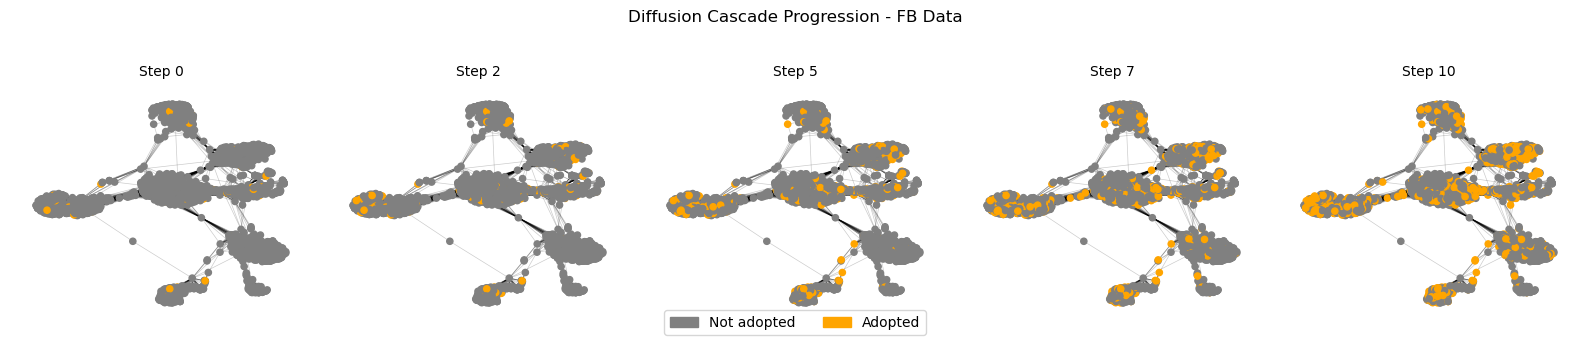

In [58]:
# Visualize Facebook diffusion snapshots

pos_fb = nx.spring_layout(G_fb, seed=42)

k_fb = min(5, len(snapshots_fb))
idxs_fb = np.linspace(0, len(snapshots_fb)-1, k_fb, dtype=int)

fig, axes = plt.subplots(1, k_fb, figsize=(3.2*k_fb, 3.2))
if k_fb == 1:
    axes = np.array([axes])

for ax, t in zip(axes, idxs_fb):
    adopted_fb = snapshots_fb[t]
    colors_fb = np.where(adopted_fb == 1, 'orange', 'gray')
    nx.draw_networkx_nodes(G_fb, pos_fb, node_color=colors_fb, node_size=20, ax=ax)
    nx.draw_networkx_edges(G_fb, pos_fb, alpha=0.2, width=0.5, ax=ax)
    ax.set_title(f"Step {t}", fontsize=10)
    ax.axis('off')

gray_patch_fb = mpatches.Patch(color='gray', label='Not adopted')
orange_patch_fb = mpatches.Patch(color='orange', label='Adopted')
fig.legend(handles=[gray_patch_fb, orange_patch_fb], loc='lower center', ncol=2, frameon=True)

fig.suptitle("Diffusion Cascade Progression - FB Data", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


## 5) Graph Anomaly Detection (DOMINANT-style)

### Synthetic Data

[Epoch 0] total=0.9747 A=0.2929 X=1.9973
[Epoch 50] total=0.7277 A=0.2586 X=1.4315
[Epoch 100] total=0.6404 A=0.2557 X=1.2176
[Epoch 150] total=0.6147 A=0.2554 X=1.1538
Anomaly Detection AUROC: 1.0 AP: 1.0


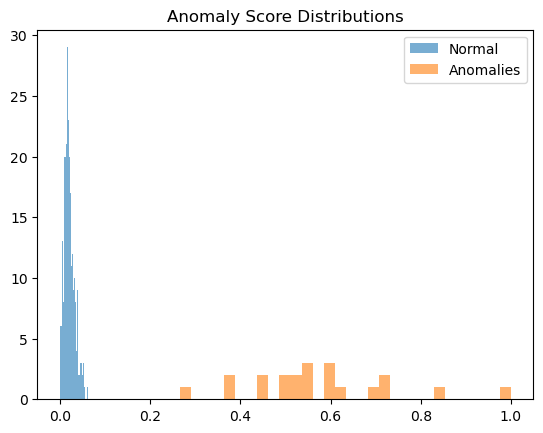

In [37]:

def inject_anomalies(A_dense, X, frac=0.07, feat_scale=5.0, rewire_prob=0.6):
    n = A_dense.shape[0]
    k = int(frac * n)
    idx = np.random.choice(n, size=k, replace=False)
    X_anom = X.clone()
    X_anom[idx] += feat_scale * torch.randn_like(X_anom[idx])
    A2 = A_dense.clone()
    for i in idx:
        for j in range(n):
            if i==j: continue
            if np.random.rand() < rewire_prob:
                A2[i,j] = 1 - A2[i,j]
                A2[j,i] = A2[i,j]
    deg = A2.sum(1).clamp(min=1.0)
    D_inv = torch.pow(deg, -0.5)
    D = torch.diag(D_inv)
    A_hat2 = D @ A2 @ D
    labels = torch.zeros(n, dtype=torch.long, device=device); labels[idx] = 1
    return A_hat2.to(device), X_anom.to(device), labels

A_hat2, X_anom, y_anom = inject_anomalies((A>0).float(), X)

class GraphAE(nn.Module):
    def __init__(self, in_dim, hid_dim, emb_dim, dropout=0.2):
        super().__init__()
        self.e1 = GCNLayer(in_dim, hid_dim)
        self.e2 = GCNLayer(hid_dim, emb_dim)
        self.decX = nn.Linear(emb_dim, in_dim)
        self.dropout = dropout
    def forward(self, A_hat, X):
        H = F.relu(self.e1(A_hat, X))
        H = F.dropout(H, p=self.dropout, training=self.training)
        Z = self.e2(A_hat, H)
        X_hat = self.decX(Z)
        A_hat_pred = torch.sigmoid(Z @ Z.T)
        return Z, X_hat, A_hat_pred

gae = GraphAE(in_dim, 64, 32, 0.2).to(device)
opt = torch.optim.Adam(gae.parameters(), lr=0.01)

A_target = (A_hat2 > 0).float()
def recon_loss(A_t, A_p, X_t, X_p, alpha=0.6):
    la = F.mse_loss(A_p, A_t)
    lx = F.mse_loss(X_p, X_t)
    return alpha*la + (1-alpha)*lx, la.item(), lx.item()

for epoch in range(200):
    gae.train()
    Z, X_hat, A_hat_pred = gae(A_hat2, X_anom)
    loss, la, lx = recon_loss(A_target, A_hat_pred, X_anom, X_hat, alpha=0.6)
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"[Epoch {epoch}] total={loss.item():.4f} A={la:.4f} X={lx:.4f}")

gae.eval()
with torch.no_grad():
    Z, X_hat, A_hat_pred = gae(A_hat2, X_anom)
    feat_err = ((X_anom - X_hat)**2).mean(dim=1)
    adj_err = ((A_target - A_hat_pred)**2).mean(dim=1)
    score = 0.5*feat_err + 0.5*adj_err
    score = (score - score.min())/(score.max()-score.min() + 1e-8)
    auroc = roc_auc_score(y_anom.cpu().numpy(), score.cpu().numpy())
    ap = average_precision_score(y_anom.cpu().numpy(), score.cpu().numpy())
print("Anomaly Detection AUROC:", round(auroc,3), "AP:", round(ap,3))

plt.figure()
plt.hist(score[y_anom==0].cpu().numpy(), bins=30, alpha=0.6, label='Normal')
plt.hist(score[y_anom==1].cpu().numpy(), bins=30, alpha=0.6, label='Anomalies')
plt.legend(); plt.title('Anomaly Score Distributions'); plt.show()


/var/folders/5x/87gs962j3hzbnvy7dy2jv5280000gn/T/ipykernel_94123/3054574491.py:21: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


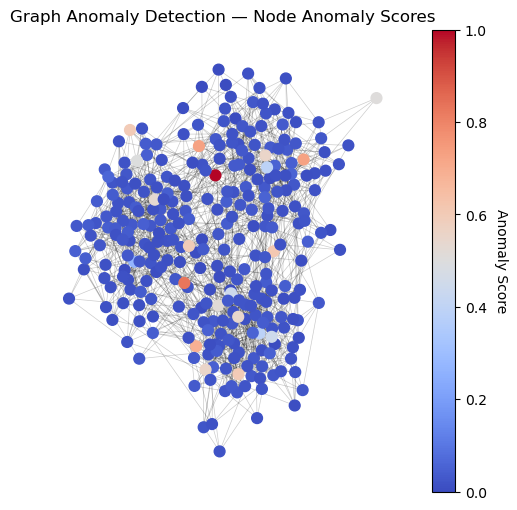

In [38]:
# Visualize anomaly scores
gae.eval()
with torch.no_grad():
    Z, X_hat, A_hat_pred = gae(A_hat2, X_anom)
    feat_err = ((X_anom - X_hat)**2).mean(dim=1)
    adj_err = ((A_target - A_hat_pred)**2).mean(dim=1)
    score = 0.5*feat_err + 0.5*adj_err
    score = (score - score.min()) / (score.max()-score.min() + 1e-8)
score_np = score.cpu().numpy()

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(6,6))
nodes = nx.draw_networkx_nodes(G, pos, node_color=score_np, cmap='coolwarm', node_size=60)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)
plt.title("Graph Anomaly Detection — Node Anomaly Scores", fontsize=12)
plt.axis('off')

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap='coolwarm')
sm.set_array(score_np)
cbar = plt.colorbar(sm)
cbar.set_label('Anomaly Score', rotation=270, labelpad=15)
plt.show()


### Real Data

In [39]:
class Autoencoder_fb(torch.nn.Module):
    def __init__(self, in_dim, hid_dim):
        super().__init__()
        self.enc = torch.nn.Linear(in_dim, hid_dim)
        self.dec = torch.nn.Linear(hid_dim, in_dim)
    def forward(self, X):
        Z = torch.relu(self.enc(X))
        X_hat = self.dec(Z)
        return Z, X_hat

autoencoder_fb = Autoencoder_fb(X_fb.shape[1], 64).to(device)
opt_auto_fb = torch.optim.Adam(autoencoder_fb.parameters(), lr=0.01)

for epoch in range(150):
    autoencoder_fb.train()
    Z_fb, X_hat_fb = autoencoder_fb(X_fb)
    recon_loss_fb = ((X_fb - X_hat_fb)**2).mean()
    opt_auto_fb.zero_grad(); recon_loss_fb.backward(); opt_auto_fb.step()
    if epoch % 30 == 0:
        print(f"[FB][Anomaly Epoch {epoch}] loss={recon_loss_fb.item():.4f}")

with torch.no_grad():
    _, X_hat_fb = autoencoder_fb(X_fb)
    anom_score_fb = ((X_fb - X_hat_fb)**2).sum(1).cpu().numpy()


[FB][Anomaly Epoch 0] loss=1.0553
[FB][Anomaly Epoch 30] loss=0.0212
[FB][Anomaly Epoch 60] loss=0.0049
[FB][Anomaly Epoch 90] loss=0.0034
[FB][Anomaly Epoch 120] loss=0.0028


[Facebook] Highlighting top 1.0% = 40 anomalous nodes


/var/folders/5x/87gs962j3hzbnvy7dy2jv5280000gn/T/ipykernel_94123/2148843454.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("coolwarm"),


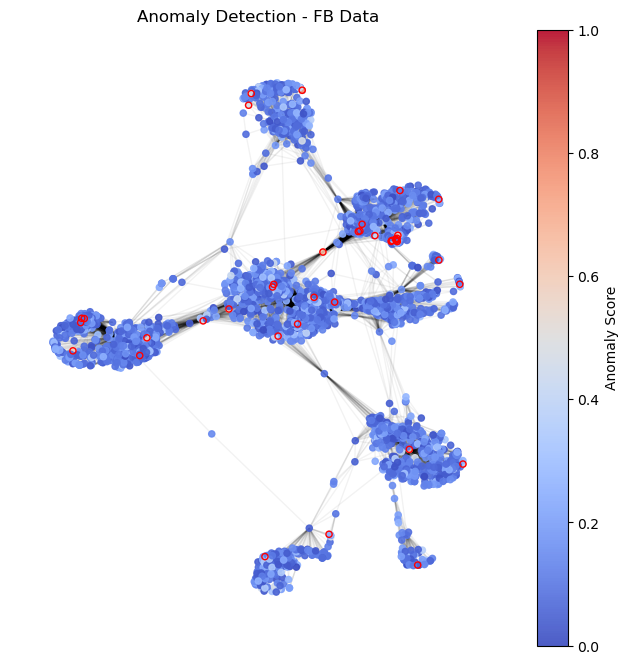

In [68]:
# Normalize anomaly scores to [0,1]
anom_norm_fb = (anom_score_fb - anom_score_fb.min()) / (anom_score_fb.max() - anom_score_fb.min())

# Choose top anomalies (for highlighting)
top_ratio_fb = 0.01  
topk_fb = int(top_ratio_fb * len(anom_norm_fb))
threshold_fb = np.sort(anom_norm_fb)[-topk_fb]
top_nodes_fb = np.where(anom_norm_fb >= threshold_fb)[0]

print(f"[Facebook] Highlighting top {100*top_ratio_fb:.1f}% = {len(top_nodes_fb)} anomalous nodes")

# Visualization
plt.figure(figsize=(8,8))
nx.draw_networkx_edges(G_fb, pos_fb, alpha=0.05, width=1, edge_color="black")

# Color all nodes by anomaly score
nodes_fb = nx.draw_networkx_nodes(
    G_fb, pos_fb,
    node_color=anom_norm_fb,
    cmap=cm.get_cmap("coolwarm"),
    node_size=20,
    alpha=0.9
)

# Outline top anomalies for emphasis
nx.draw_networkx_nodes(
    G_fb, pos_fb,
    nodelist=top_nodes_fb,
    node_color="none",
    edgecolors="red",
    linewidths=1,
    node_size=20
)

plt.colorbar(nodes_fb, label="Anomaly Score")
plt.title("Anomaly Detection - FB Data", fontsize=12)
plt.axis("off")
plt.show()
